# Exercise 2 — Dados sobrepostos

Execute as células em ordem. Para reproduzir **o mesmo estado** do gerador `rng` do relatório, a primeira célula avança a geração e o sorteio inicial do Exercício 1 antes de gerar o segundo conjunto. A implementação do modelo é a mesma do [Exercise 1](Exercise1.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from perceptron import make_dataset, train, predict, accuracy
from run_analysis import scatter_classes, boundary, mark_errors
rng = np.random.default_rng(42)

## A — Generate the data

Geramos 1.000 pontos da classe 0, $\mathcal N([3,3],1{,}5I)$, e 1.000 da classe 1, $\mathcal N([4,4],1{,}5I)$. As nuvens se sobrepõem fortemente.

Formato: (2000, 2) | contagens: [1000 1000]


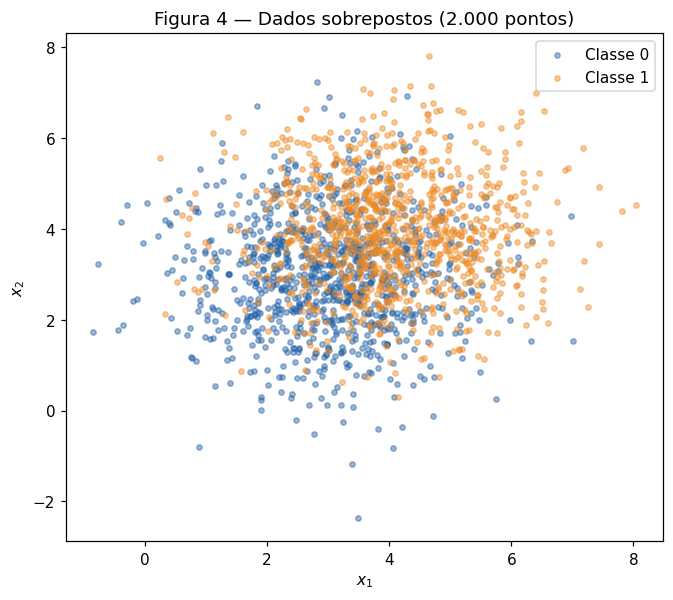

In [2]:
# Avanço do único gerador para o mesmo estado do relatório.
_ = make_dataset(rng, [1.5, 1.5], [5, 5], .5)
_ = rng.normal(0, 0.01, size=2)
x2, y2 = make_dataset(rng, [3, 3], [4, 4], 1.5)
print('Formato:', x2.shape, '| contagens:', np.bincount(y2))
fig, ax = plt.subplots(figsize=(7, 6))
scatter_classes(ax, x2, y2)
ax.set_title('Figura 4 — Dados sobrepostos (2.000 pontos)')
plt.show()

## B — Train, keeping the best weights

A função `train` recebe os mesmos parâmetros do Exercício 1 e `pocket=True`. Após cada erro, mede a acurácia total e salva uma **cópia** apenas quando ela supera o recorde. Os pesos finais permanecem separados do pocket. Após **100 épocas**, o estado final é $\mathbf w=[0{,}054484,0{,}048043]$, $b=-0{,}070000$, com **50,15%**. O pocket é $\mathbf w=[0{,}010664,0{,}008727]$, $b=-0{,}070000$, com **71,10%**; sua última melhora ocorreu na época **86**.

In [3]:
fit2 = train(x2, y2, rng, eta=.01, max_epochs=100, pocket=True)
print(f'Final: épocas={fit2.epochs}, w={fit2.weights}, b={fit2.bias:.6f}, acurácia={fit2.accuracies[-1]:.2%}')
print(f'Pocket: época da melhor atualização={fit2.pocket_epoch}, w={fit2.pocket_weights}, b={fit2.pocket_bias:.6f}, acurácia={fit2.pocket_accuracy:.2%}')

Final: épocas=100, w=[0.05448404 0.0480433 ], b=-0.070000, acurácia=50.15%
Pocket: época da melhor atualização=86, w=[0.01066397 0.00872652], b=-0.070000, acurácia=71.10%


## C — Figures

A Figura 5 compara as duas fronteiras sobre os mesmos dados; círculos vermelhos mostram os erros de cada estado. A Figura 6 mostra a acurácia dos pesos atuais e o melhor resultado acumulado após cada época.

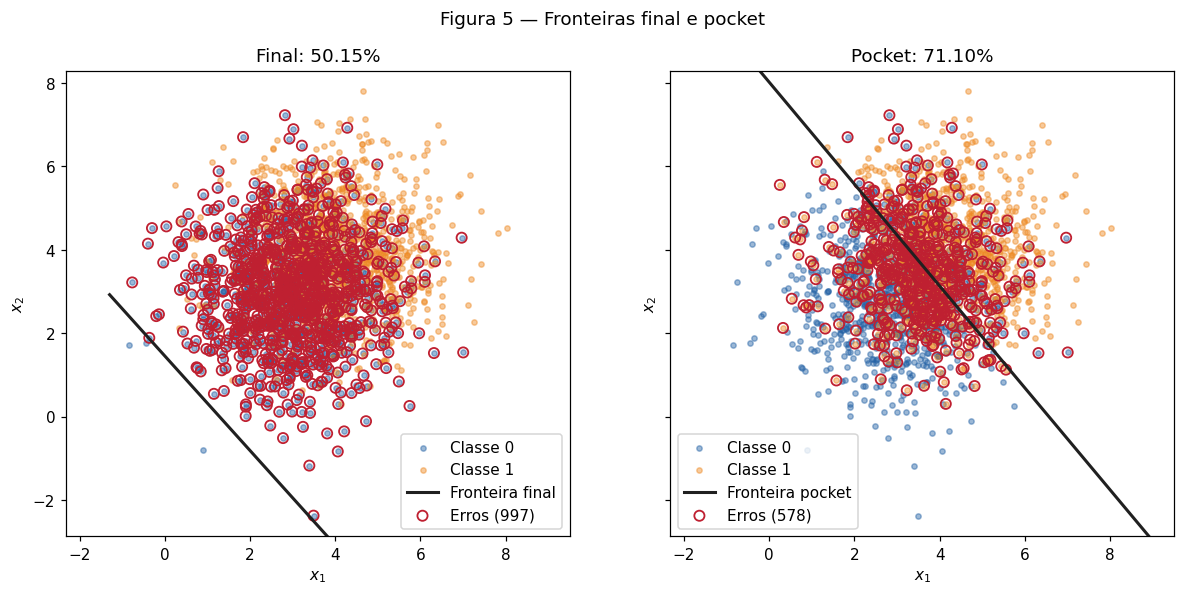

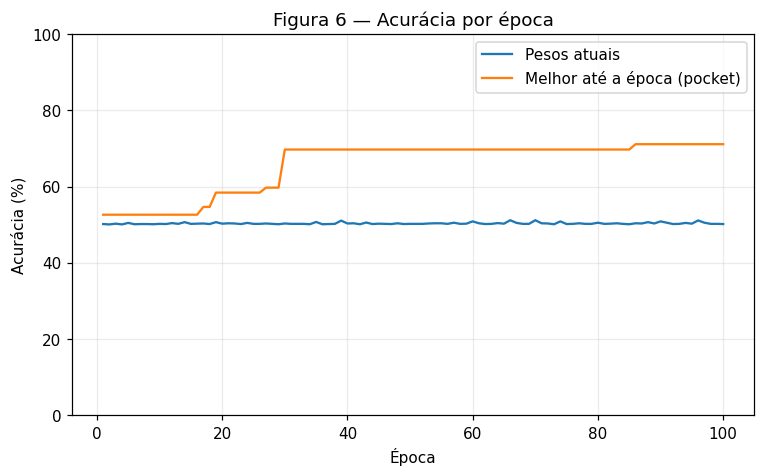

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, weights, bias, name in ((axes[0], fit2.weights, fit2.bias, 'final'),
                                (axes[1], fit2.pocket_weights, fit2.pocket_bias, 'pocket')):
    scatter_classes(ax, x2, y2)
    boundary(ax, weights, bias, ax.get_xlim(), f'Fronteira {name}')
    mark_errors(ax, x2, y2, weights, bias)
    ax.set_ylim(x2[:, 1].min()-.5, x2[:, 1].max()+.5)
    ax.set_title(f'{name.capitalize()}: {accuracy(x2,y2,weights,bias):.2%}')
    ax.legend()
fig.suptitle('Figura 5 — Fronteiras final e pocket')
plt.show()
fig, ax = plt.subplots(figsize=(8, 4.5))
epochs = np.arange(1, fit2.epochs+1)
ax.plot(epochs, np.array(fit2.accuracies)*100, label='Pesos atuais')
ax.plot(epochs, np.array(fit2.pocket_curve)*100, label='Melhor até a época (pocket)')
ax.set(xlabel='Época', ylabel='Acurácia (%)', title='Figura 6 — Acurácia por época')
ax.set_ylim(0, 100); ax.grid(alpha=.25); ax.legend()
plt.show()

## D — Analysis

1. O pocket atinge **71,10%**, perto do patamar de 73% do enunciado; o estado final fica em **50,15%**. A reta final passa abaixo da região central e prevê quase tudo como classe 1. Por erro, $|\Delta b|=0{,}01$ e $\|\Delta w\|=0{,}01\|x\|\approx0{,}05$, pois $\|x\|\approx5$. As últimas correções podem mover a reta para um estado ruim; o pocket preserva a melhor encontrada.
2. A Figura 3 do Exercício 1 chega a 100%; a Figura 6 oscila. O teorema de convergência exige separabilidade linear com margem positiva, violada por estes dados sobrepostos.
3. Mais épocas não eliminam a incompatibilidade entre exemplos; somente dão ao pocket outras oportunidades. Reduzir $\eta$ escala peso e viés juntos: $\|\Delta w\|/|\Delta b|=\|x\|$ continua próximo de 5. A taxa pode alterar a trajetória, mas não torna os dados separáveis.